# pred-2: mining the thread annotations

The 21,803 genuine multi-party exchanges were each turned into one structured
row by an LLM annotator working to a fixed schema (`ANNOTATION_SCHEMA.md`), with
every row validated against a Pydantic model before it reached
`thread_annotations.parquet`. This notebook mines that table: what Enron talked
about, where the executives actually sit, and which conversations carry the asks
and the decisions. The categorical fields come from the model; the per-thread
meta (executive involvement, outcome, message counts) is deterministic from the
cleaned corpus, so the two can be crossed without circularity.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "pred-2" / "thread_annotations.parquet").exists():
            return base
    raise FileNotFoundError("thread_annotations.parquet not found")
ROOT = find_root()
PLOTS = ROOT / "pred-2" / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#6a3d9a"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

df = pd.read_parquet(ROOT / "pred-2" / "thread_annotations.parquet")
PRETTY = {"deal-contract": "Deals & contracts", "internal-admin": "Internal / admin",
    "social": "Social", "trading-risk": "Trading & risk", "scheduling-logistics": "Scheduling",
    "legal-regulatory": "Legal / regulatory", "report-fyi": "Reports / FYI",
    "california-energy": "California crisis"}
print(f"{len(df):,} annotated threads; executives in {df.involves_executive.mean():.0%}, "
      f"a request in {df.has_request.mean():.0%}, a decision in {df.has_decision.mean():.0%}")

21,803 annotated threads; executives in 36%, a request in 73%, a decision in 31%


## What Enron emailed about

Each thread carries one dominant purpose and one outcome. Sorted by volume, the
mix is led by deals and contracts and by internal administration, with the
substantive business categories (deals, the California crisis, legal) the ones
most often left `open`: the captured mailboxes catch those conversations
mid-flight, where social and FYI threads close quickly.

/tmp/ipykernel_469406/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


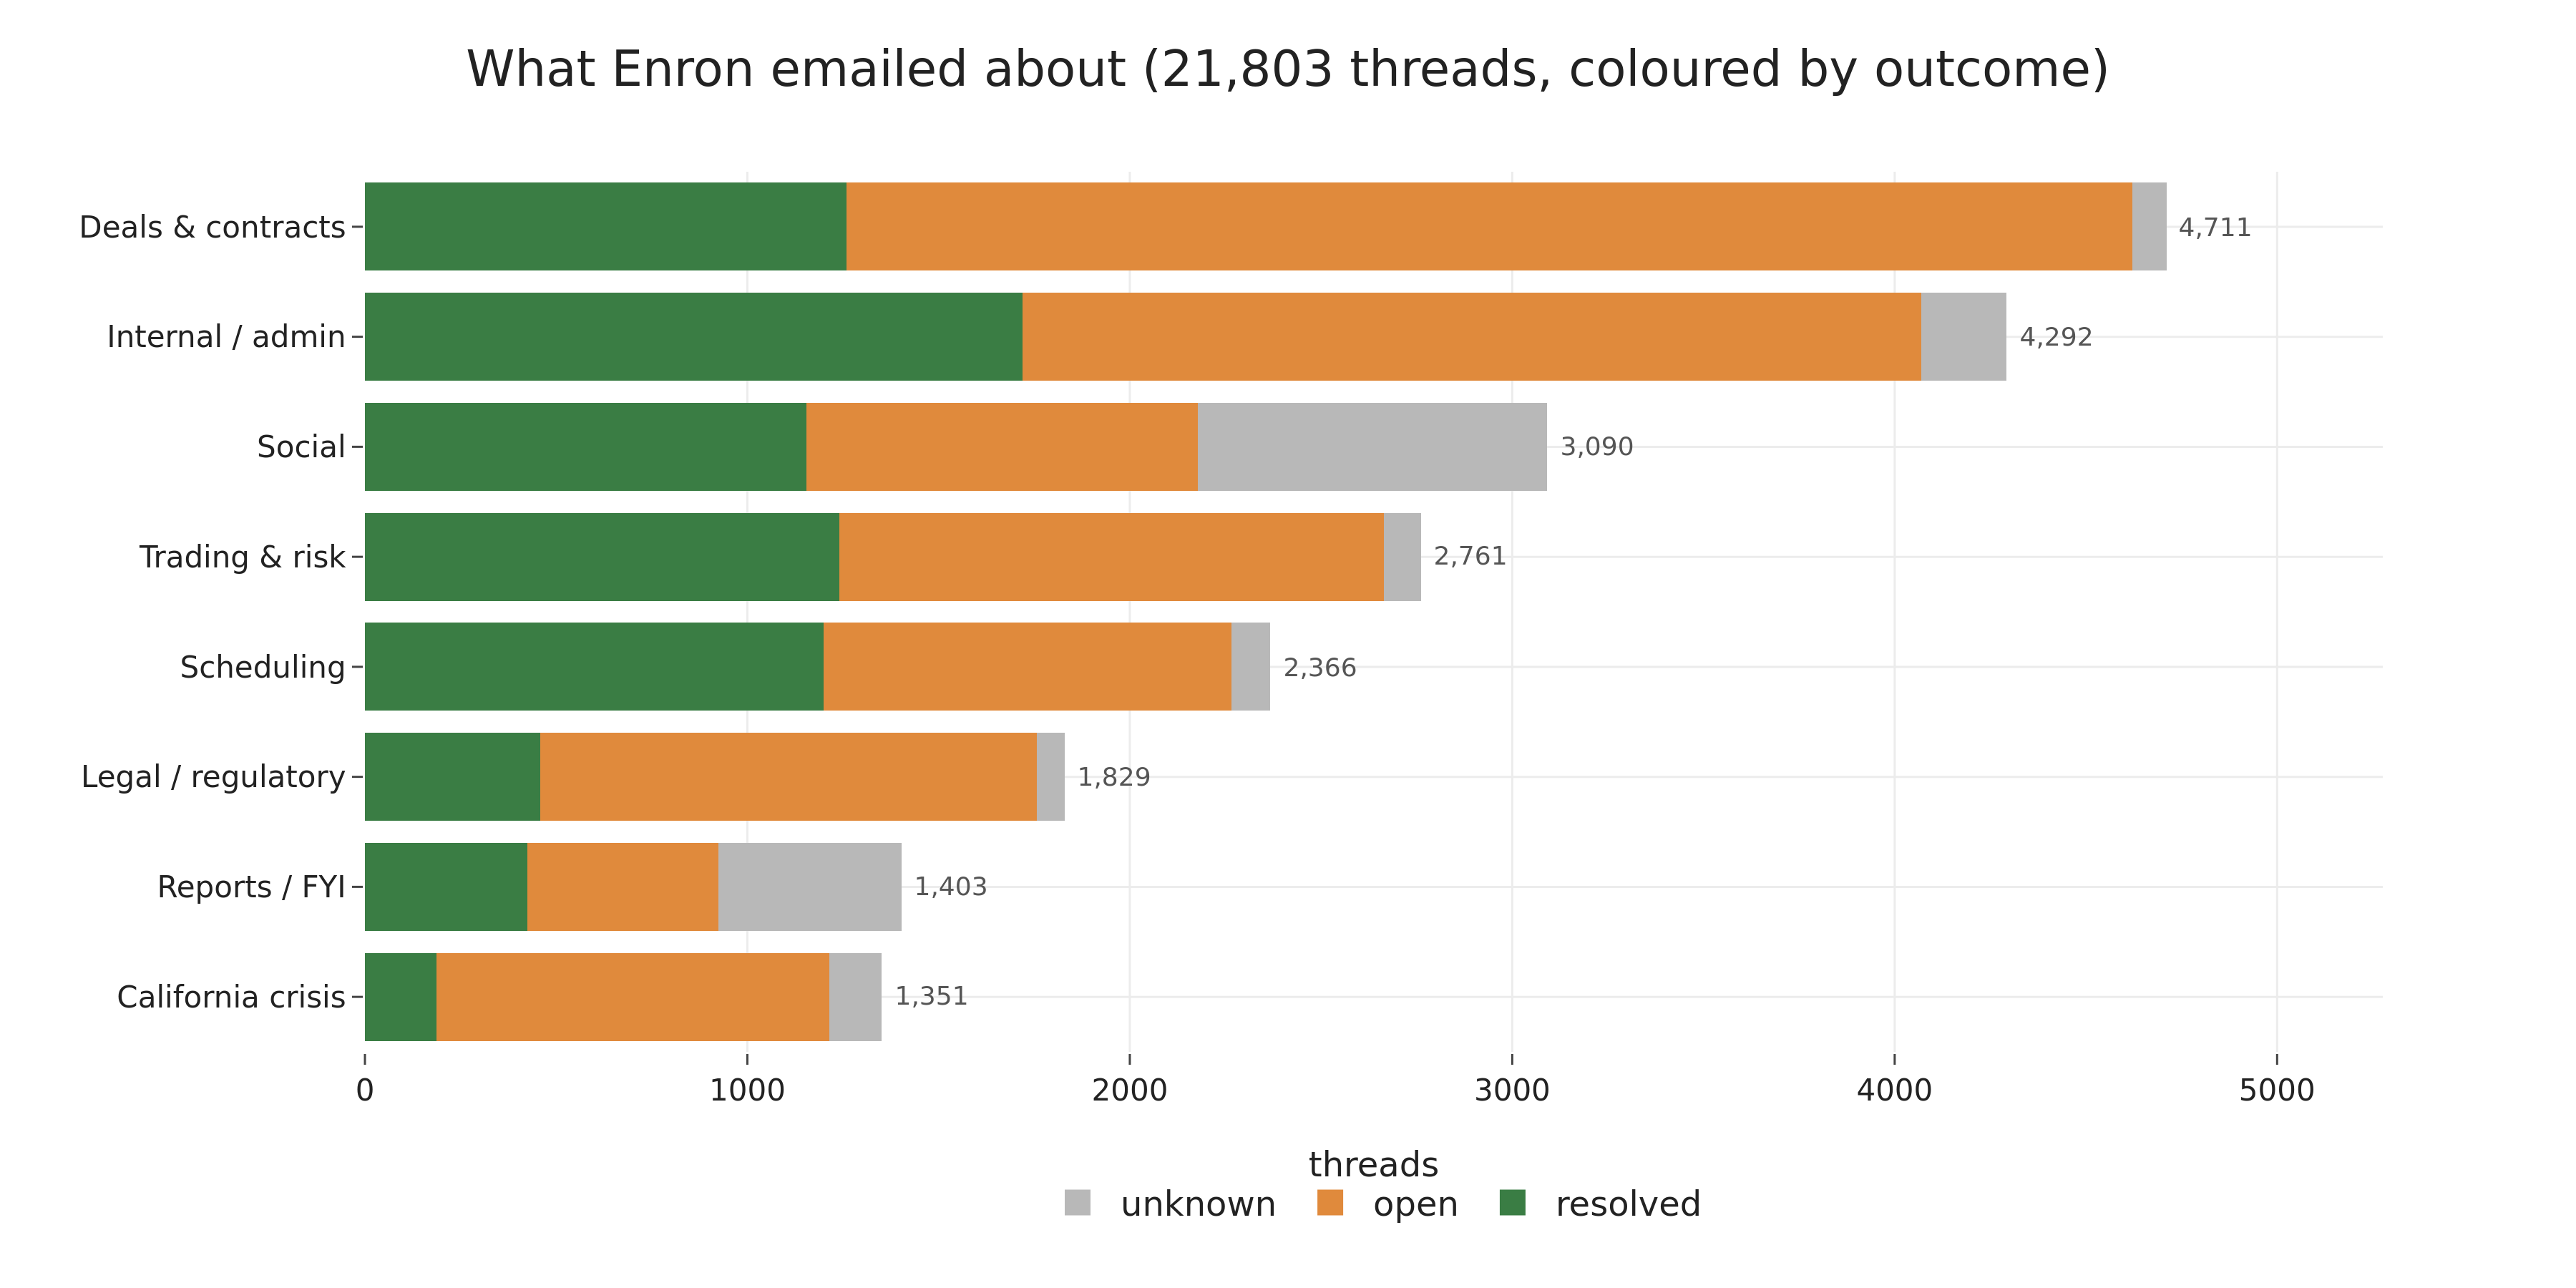

In [2]:
order = df["category"].value_counts().index.tolist()
oc = (df.groupby(["category", "outcome"]).size().unstack(fill_value=0)
        .reindex(order)[["resolved", "open", "unknown"]])
labels = [PRETTY[c] for c in order]
fig = go.Figure()
for outcome, col in [("resolved", GREEN), ("open", ORANGE), ("unknown", GREY)]:
    fig.add_trace(go.Bar(y=labels, x=oc[outcome], name=outcome, orientation="h", marker_color=col))
totals = oc.sum(axis=1)
for i, t in enumerate(totals):
    fig.add_annotation(x=t, y=labels[i], text=f" {t:,}", showarrow=False, xanchor="left",
        font=dict(size=12, color="#555"))
fig.update_yaxes(autorange="reversed")
fig.update_xaxes(title_text="threads", range=[0, totals.max() * 1.12])
fig.update_layout(title="What Enron emailed about (21,803 threads, coloured by outcome)",
    barmode="stack", legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.13, yanchor="top"))
save_fig(fig, "tm1_corpus_composition.png", w=1200, h=600, margin=dict(l=170, r=90, t=80, b=110))

## Where the executives actually sit

Crossing the LLM category with the deterministic executive flag shows a sharp
split. Executives appear in 36% of threads overall, but in nearly three quarters
of the California-crisis threads and roughly half of scheduling and legal ones,
while they turn up in only about a fifth of the deal-contract and trading
threads. The operational deal and trading engine runs below them; the executive
layer lives in the crisis, the regulators and the coordination. This is the
content-side echo of pred-2, where seniority was predictable from metadata: here
it shows up in which conversations a person joins.

/tmp/ipykernel_469406/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


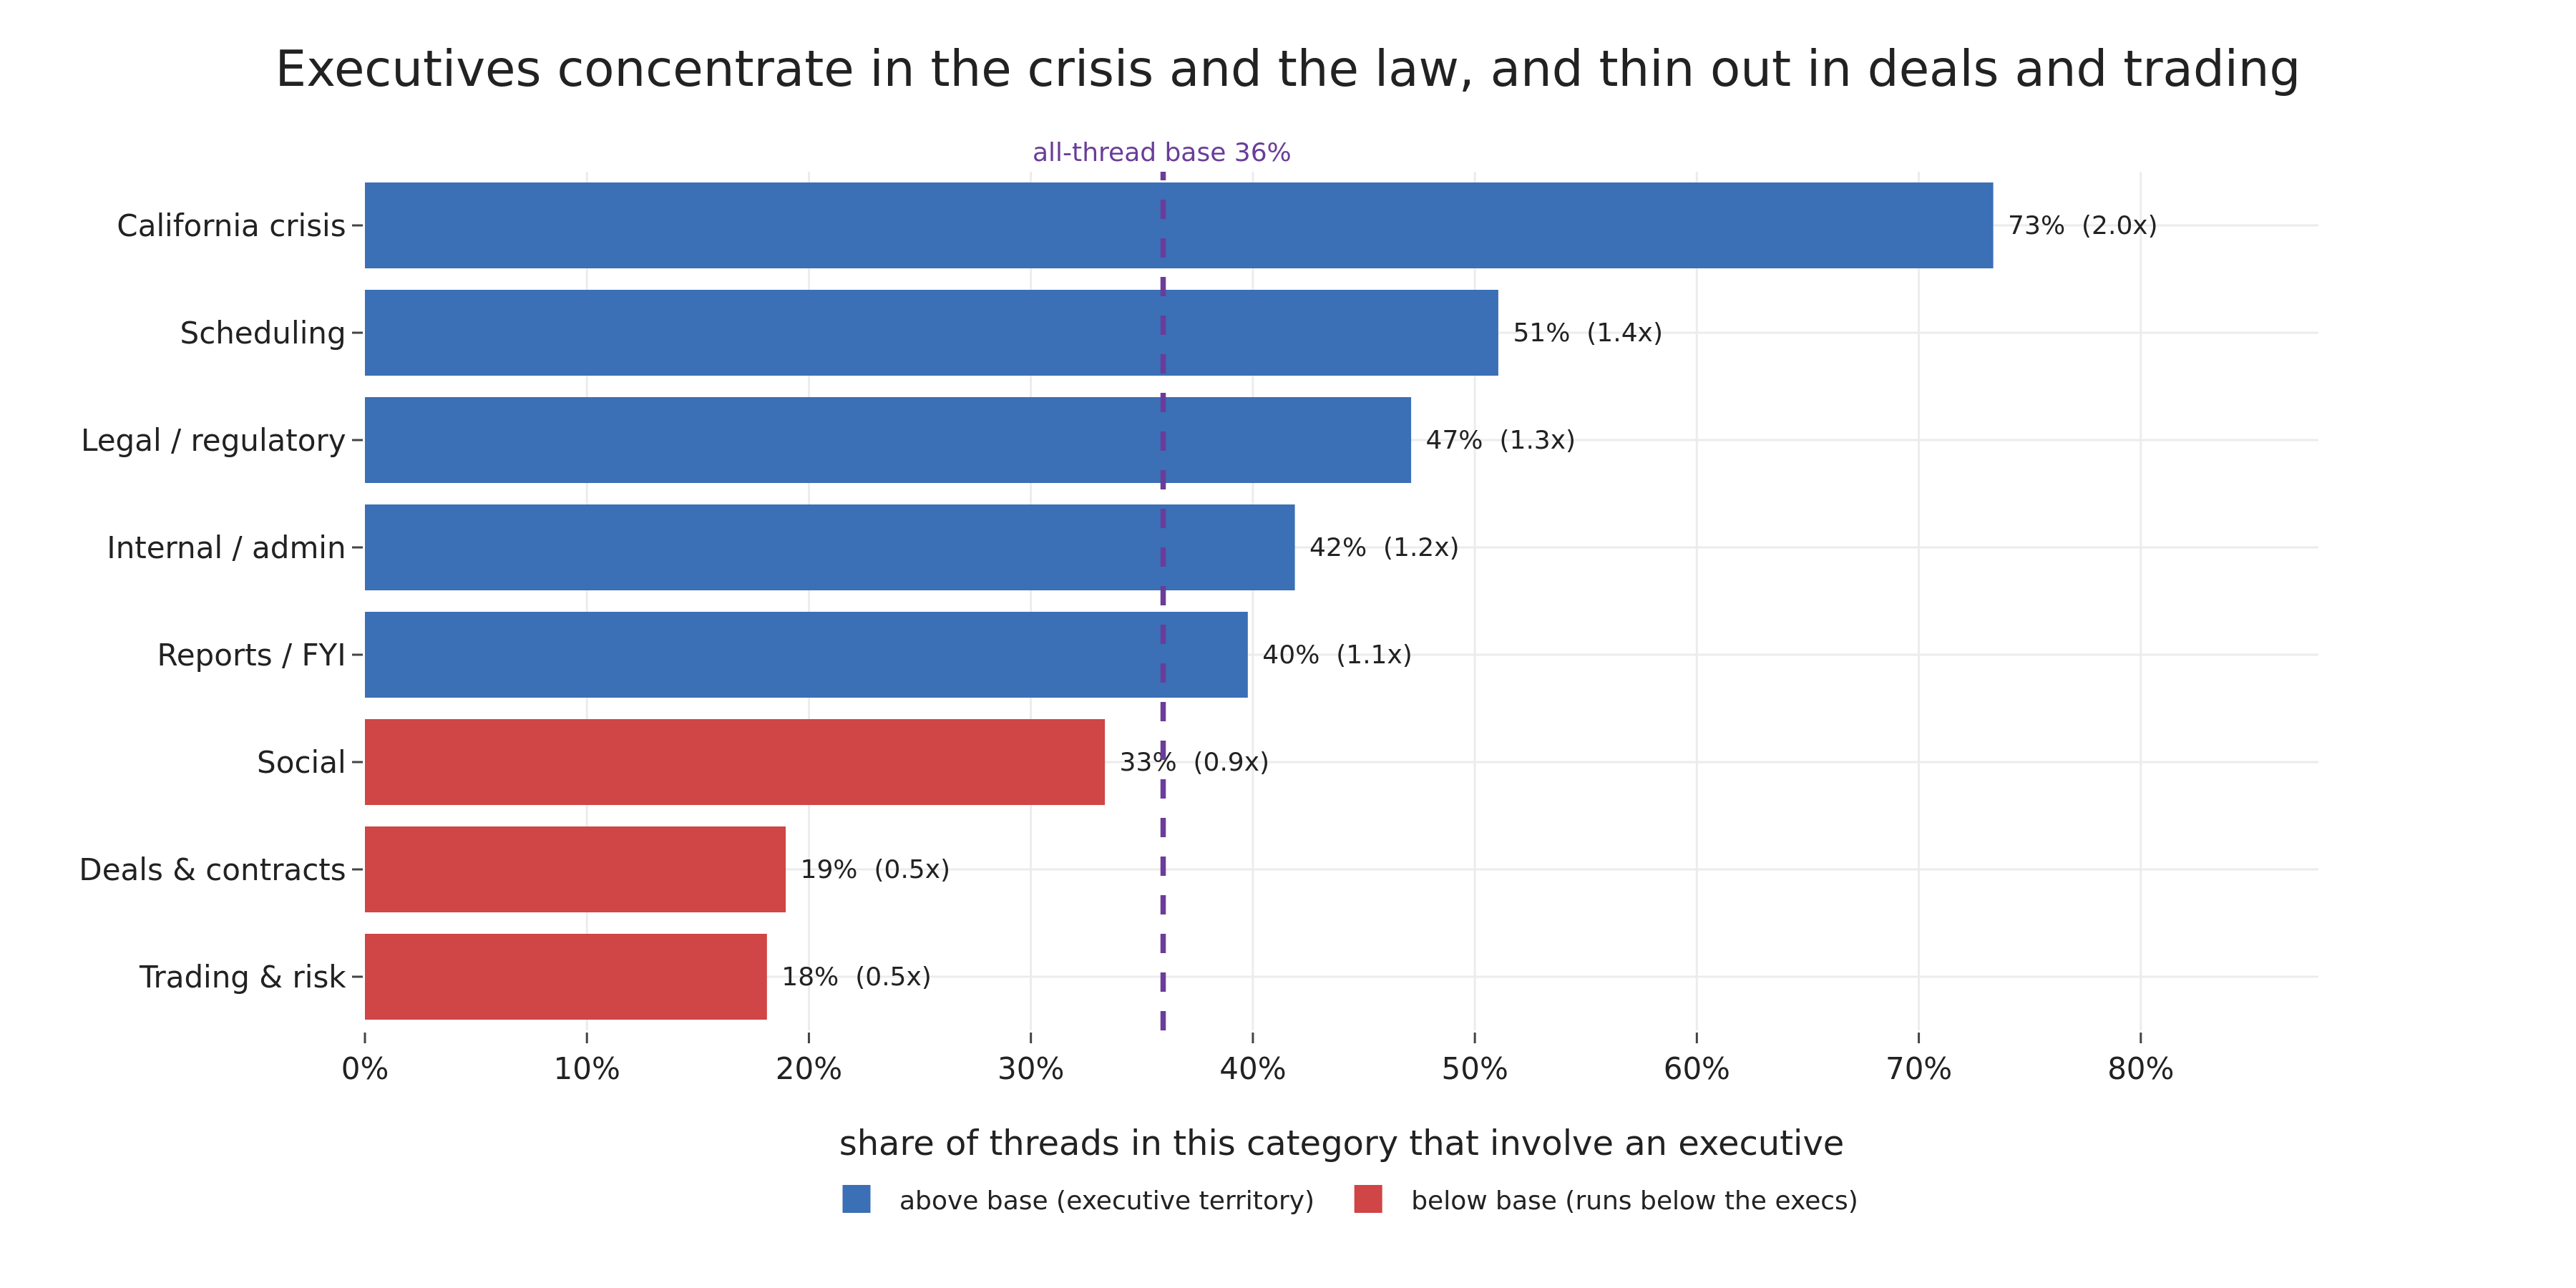

In [3]:
base = df["involves_executive"].mean()
er = df.groupby("category")["involves_executive"].mean().sort_values()
labels = [PRETTY[c] for c in er.index]
cols = [BLUE if v >= base else RED for v in er.values]
fig = go.Figure(go.Bar(y=labels, x=er.values * 100, orientation="h", marker_color=cols,
    text=[f" {v*100:.0f}%  ({v/base:.1f}x)" for v in er.values], textposition="outside",
    textfont=dict(size=12), cliponaxis=False, showlegend=False))
fig.add_vline(x=base * 100, line=dict(color=PURPLE, dash="dash", width=2.5),
    annotation_text=f"all-thread base {base:.0%}", annotation_position="top",
    annotation_font=dict(size=12, color=PURPLE))
for col, nm in [(BLUE, "above base (executive territory)"), (RED, "below base (runs below the execs)")]:
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
        marker=dict(size=13, color=col, symbol="square"), name=nm))
fig.update_xaxes(title_text="share of threads in this category that involve an executive",
    range=[0, 88], ticksuffix="%")
fig.update_layout(title="Executives concentrate in the crisis and the law, and thin out in deals and trading",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.16, yanchor="top", font=dict(size=12)))
save_fig(fig, "tm2_executives_by_topic.png", w=1200, h=600, margin=dict(l=170, r=120, t=80, b=120))

## Asks and decisions

Almost three quarters of threads contain a request, so the corpus is a working
inbox in its own right. Decisions are rarer and concentrate in the
operational categories: scheduling, trading and deals carry the most decided
or explicitly deferred conversations, while reports and social threads are
mostly one-directional.

/tmp/ipykernel_469406/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


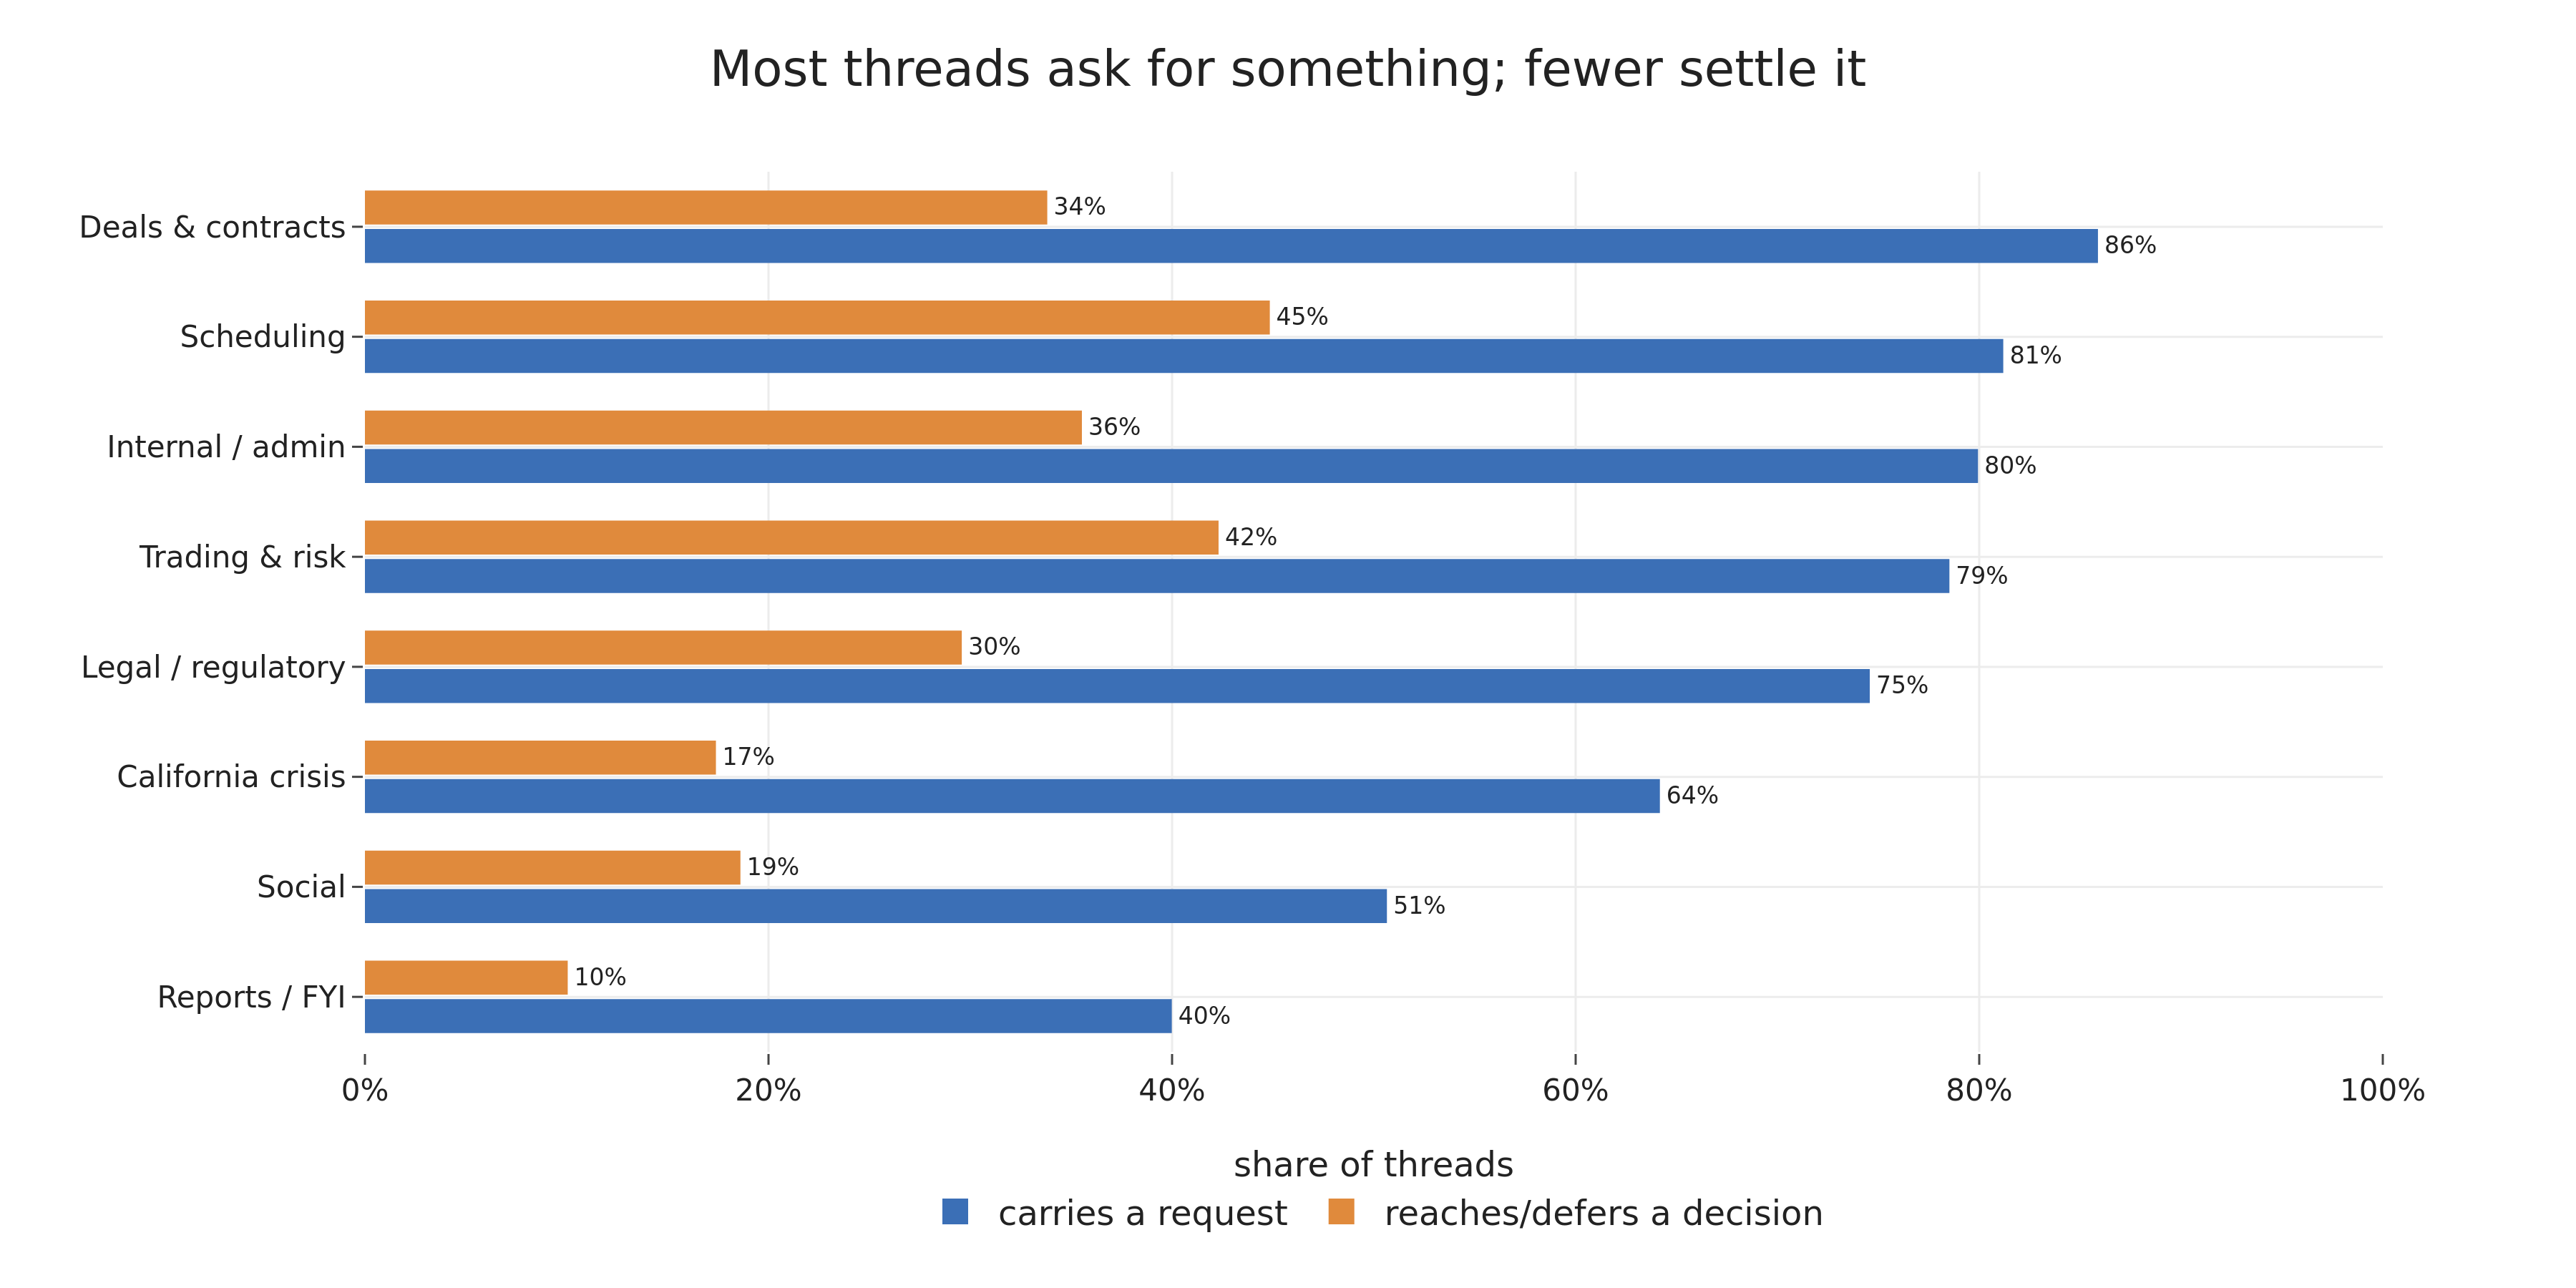

In [4]:
act = df.groupby("category").agg(req=("has_request", "mean"), dec=("has_decision", "mean"))
act = act.sort_values("req")
labels = [PRETTY[c] for c in act.index]
fig = go.Figure()
fig.add_trace(go.Bar(y=labels, x=act["req"] * 100, orientation="h", marker_color=BLUE,
    name="carries a request", text=[f"{v*100:.0f}%" for v in act["req"]], textposition="outside",
    textfont=dict(size=11), cliponaxis=False))
fig.add_trace(go.Bar(y=labels, x=act["dec"] * 100, orientation="h", marker_color=ORANGE,
    name="reaches/defers a decision", text=[f"{v*100:.0f}%" for v in act["dec"]], textposition="outside",
    textfont=dict(size=11), cliponaxis=False))
fig.update_xaxes(title_text="share of threads", range=[0, 100], ticksuffix="%")
fig.update_layout(title="Most threads ask for something; fewer settle it",
    barmode="group", bargap=0.3, bargroupgap=0.12,
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.14, yanchor="top"))
save_fig(fig, "tm3_requests_decisions.png", w=1200, h=600, margin=dict(l=170, r=90, t=80, b=110))

## What the annotations add

Read together, the three views give a content map the metadata alone could not.
Enron's mail is a working inbox dominated by deals, internal coordination and
trading, with the weightiest matters left open. Executives are not spread evenly
through it: they sit in the California crisis, the regulatory and the
coordination threads, and stay out of the operational deal and trading flow that
the rest of the company runs. That is the same seniority signal pred-2 recovered
from metadata, now legible in plain language. A per-person role read would be a
natural next pass.